# QNN Fashion-MNIST Classification（Pennylane + sklearn）
使用 QNN 來進行服裝類型衣服與褲子的二元分類 (對應手寫數字的 0 與 1)。\

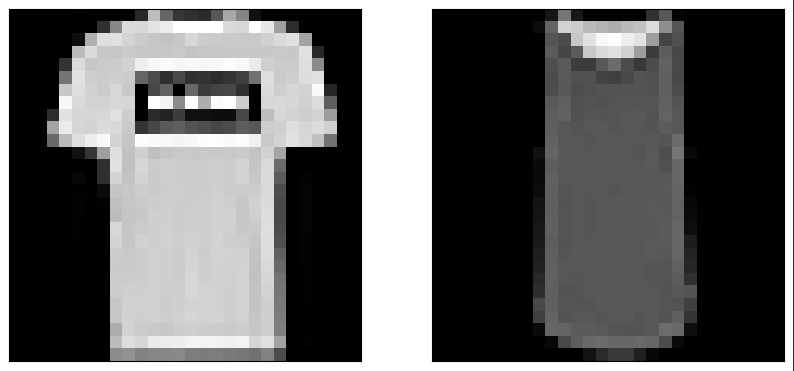

# 1️⃣ 安裝套件（Colab）

In [ ]:
!pip install pennylane          # PennyLane 是一個專門為「量子計算」設計的開源 Python 軟體庫
!pip install scikit-learn       # 用於處理一些傳統機器學習的任務，包含一些基礎的資料讀取分割功能 (後續程式碼將會使用到)

# 2️⃣ 匯入必要函式庫

In [ ]:
import matplotlib.pyplot as plt                         # 在這裡用於畫折線圖、顯示圖片

from sklearn.datasets import fetch_openml               # 用於讀取 MNIST 數據
from sklearn.decomposition import PCA                   # 用於數據降維
from sklearn.model_selection import train_test_split    # 用於資料自動分割
from sklearn.preprocessing import MinMaxScaler          # 用於縮放數據範圍
from skimage.transform import resize                    # 調整圖片長寬大小
from sklearn.metrics import confusion_matrix

import pennylane as ___                                 # pennylane 量子模型庫
from pennylane import numpy as np                       # pennylane 自帶的 numpy 庫，numpy 大幅改善了 python 數值計算緩慢的問題

# 3️⃣ Data 數據

In [ ]:
# 1. 載入並預處理資料
print("正在下載並處理 Fashion MNIST 資料...")
mnist = fetch_openml(name='Fashion-MNIST', version=1)
X_raw, y_raw = mnist.data.values, mnist.target.values

# 4️⃣ 選擇分類任務：衣服 vs 褲子 (二元分類）

In [ ]:
# 只篩選衣服 vs 褲子 (對應到 0 和 1)
mask = ___
X, y = X_raw[mask], y_raw[mask].astype(int)
print("X data shape: ", X.shape)
print("y data shape: ", y.shape)

# 查看衣服與褲子圖片
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(X[0].reshape(28, 28), cmap='gray')
ax[0].set_xticks([])
ax[0].set_yticks([])
ax[1].imshow(X[1].reshape(28, 28), cmap='gray')
ax[1].set_xticks([])
ax[1].set_yticks([])
plt.show()

# 5️⃣ 數據預處理：


In [ ]:
# Data Preprocessing
use_PCA = ___

if use_PCA:
    pca = PCA(n_components= ___ )
    Xp = pca.fit_transform(X)
    Xp = MinMaxScaler(feature_range=(0, ___)).fit_transform(Xp)
else:
    X_scaled = []
    X_image = X.reshape(len(X), 28, 28)   # 將 x reshape 成 [data個數, 28, 28]
    for i in range(len(X)):
        X_scaled.append(resize(X_image[i], ( ___ , ___ ), anti_aliasing=True))
    Xp = np.stack(X_scaled, axis = 0).reshape(len(X_image), ___ )


print("Xp shape:", Xp.shape)

In [ ]:
# 切分訓練與測試集
if use_PCA:
    X_train, X_test, y_train, y_test = train_test_split(Xp, y, train_size= ___ , test_size= ___ , random_state=42)
else:
    X_train, x_test, y_train, y_test = train_test_split(x_scaled, y, train_size= ___ , test_size= ___ , random_state=42)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("\n * 注意要確認數據 shape 正不正確")

# 6️⃣ 建構量子電路



# 以下的參數化電路是使用 HEA 結構

In [ ]:

dev = qml.device("default.qubit", wires= ___)

@qml.qnode(dev)
def circuit_HEA(num_qubits, num_layers, weights, features):
    if use_PCA:
        qml.AngleEmbedding( ___ )

    else:
        qml.AmplitudeEmbedding( ___ )

    c = 0
    for i in range(num_layers):
        for j in range(num_qubits):
            qml.U3( ___ )
            c += ___

        for j in range(num_qubits - 1):
            qml.CNOT(wires=[j, j + 1])
        qml.Barrier()

    return qml.probs( ___ )

# 以下的參數化電路是使用 QCNN 結構

In [ ]:

def Block(weights, wires):  # 15 個參數
    qml.U3(weights[0], weights[1], weights[2], wires=wires[0])
    qml.U3(weights[3], weights[4], weights[5], wires=wires[1])
    qml.CNOT(wires=[wires[0], wires[1]])
    qml.RY(weights[6], wires=wires[0])
    qml.RZ(weights[7], wires=wires[1])
    qml.CNOT(wires=[wires[1], wires[0]])
    qml.RY(weights[8], wires=wires[0])
    qml.CNOT(wires=[wires[0], wires[1]])
    qml.U3(weights[9], weights[10], weights[11], wires=wires[0])
    qml.U3(weights[12], weights[13], weights[14], wires=wires[1])


dev = qml.device("default.qubit", wires= ___ )
@qml.qnode(dev)
def circuit_QCNN(num_qubits, num_layers, weights, features):
    if use_PCA:
        qml.AngleEmbedding( ___ )
    else:
        qml.AmplitudeEmbedding( ___ )

    c = 0
    for i in range(num_layers):
        target_qubit = [j*(2**i) for j in range(num_qubits//(2**i))]
        for j in range(len(target_qubit)//2):
            Block(weights[c:c+15], wires = [target_qubit[j*2],target_qubit[j*2+1]])
        qml.Barrier()
        if i != 2:
            for j in range(len(target_qubit)//2):
                Block(weights[c:c+15], wires = [target_qubit[j*2+1],target_qubit[(j*2+2) % (8//(2**i))]])
        c += 15
        qml.Barrier()

    return qml.probs( ___ )

# 建構量子電路

In [ ]:
circuit_choose = "HEA"  # HEA or QCNN，選擇使用 HEA 還是 QCNN

# 初始化參數
num_qubits = ___
num_layers = ___

# 計算 parameter 數量
if circuit_choose == "HEA":
    num_parameters = ___
    circuit = circuit_HEA
elif circuit_choose == "QCNN":
    num_parameters = ___
    circuit = circuit_QCNN

# 隨機生成可訓練的參數
weights = np.random.uniform(low = -np.pi, high = np.pi, size = num_parameters, requires_grad=True)

# 畫出電路圖
qml.draw_mpl(circuit)(num_qubits, num_layers, weights, X_train[0])

# 7️⃣ 定義損失函數


In [ ]:
def loss_func(weights, x, y):
    predictions = np.array([circuit(num_qubits, num_layers, weights, data)[1] for data in x])
    loss = np.mean((predictions - y)**2)
    return loss

# 8️⃣ 訓練 QNN 模型

In [ ]:
# 4. 開始訓練。
# 注意每次執行這段程式碼後，參數會重製，所以會需要重新訓練
step = ___
batch_size = ___
learning_rate = ___
opt = qml.AdamOptimizer(stepsize=learning_rate)
loss_list = []

start = 0
total_step = 0

weights = np.random.uniform(low = ___ , high = ___ , size = num_parameters, requires_grad=True)

In [ ]:
print("開始訓練量子模型...")
for i in range(start, step):
    batch_index = np.random.randint(0, len(X_train), (batch_size,))
    X_batch = X_train[batch_index]
    y_batch = y_train[batch_index]

    weights, loss = opt.step_and_cost(lambda w: loss_func( ___ ), weights)
    loss_list.append(loss)

    if (total_step + 1) % 5 == 0:
        print(f"Step {total_step+1:3d} | Loss: {loss:.4f}")
    total_step += 1

# 9️⃣ 結果圖 ①: Test data 準確度、Loss 下降圖

In [ ]:
# 5. 測試準確度
def predict(weights, X_test):
    predictions = [circuit(num_qubits, num_layers, weights, data)[1] for data in ___ ]
    return [1 if prediction > 0.5 else 0 for prediction in predictions]

y_pred = predict(weights, X_test)
accuracy = np.mean(y_pred == y_test)
print(f"\n測試集準確度: {accuracy * 100:.2f}%")


# loss 變化折線圖 (Loss 有下降代表有在訓練)
plt.plot(loss_list)
plt.xlabel("Step")
plt.ylabel("Cost")
plt.title("Loss vs Step")
plt.show()

# 🔟 結果圖 ②: 混淆矩陣熱圖

In [ ]:
# 6. 混淆矩陣 (confusion matrix)
cm = confusion_matrix(y_test, y_pred)
classes = [ ___ ]

plt.figure(figsize=(4.5, 4))
plt.imshow(cm, interpolation="nearest")
plt.title("QSVM Confusion Matrix")
plt.colorbar()
plt.xticks(np.arange(len(classes)), classes)
plt.yticks(np.arange(len(classes)), classes)

thresh = cm.max() / 2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], "d"),
                 ha="center", va="center",
                 color="white" if cm[i, j] > thresh else "black")

plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.show()